In [2]:
# Cell 0 — Setup (FIXED)

# Install correct packages
!pip install -q kagglehub timm grad-cam

from google.colab import drive
from pathlib import Path
import json, os, gc, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import timm
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report, cohen_kappa_score)

# Correct import (package is grad-cam, module is pytorch_grad_cam)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import warnings
warnings.filterwarnings('ignore')

# Mount drive
drive.mount('/content/drive')

KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB7_OUT = KOA_ROOT / 'NB7'
NB7_OUT.mkdir(parents=True, exist_ok=True)
SAVE_DIR = KOA_ROOT / 'saved_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Download datasets
import kagglehub
kaggle_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")
mendeley_path = kagglehub.dataset_download("tommyngx/digital-knee-xray")

def find_split_root(base):
    base = Path(base)
    for p in [base] + list(base.rglob('*')):
        if p.is_dir() and (p / 'train').is_dir():
            return p
    return base

kaggle_root = find_split_root(kaggle_path)
mendeley_root = Path(mendeley_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("Kaggle root:", kaggle_root)
print("Mendeley root:", mendeley_root)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
Using Colab cache for faster access to the 'knee-osteoarthritis-dataset-with-severity' dataset.
Using Colab cache for faster access to the 'digital-knee-xray' dataset.
Device: cuda
Kaggle root: /kaggle/input/knee-osteoarthritis-dataset-with-severity
Mendeley root: /kaggle/input/digital-knee-xray


In [3]:
# Cell 1 — Dataset + Transforms
IMG_SIZE = 224
BEST_ARCH = 'ConvNeXt-L'
MODEL_NAME = 'convnext_large'
BEST_SEED = 42

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
vis_transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

class KneeDataset(Dataset):
    def __init__(self, df, transform, label_col='grade'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row.path).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        return self.transform(img), int(row[self.label_col]), row.path

records = []
for split in ['test']:
    split_dir = kaggle_root / split
    if not split_dir.exists():
        continue
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        try:
            grade = int(grade_dir.name)
        except ValueError:
            continue
        for img_path in sorted(grade_dir.glob('*')):
            if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                records.append({'path': str(img_path), 'grade': grade})
test_df = pd.DataFrame(records)
print(f"Kaggle test: {len(test_df)} images")

grade_map = {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
ext_records = []
for d in mendeley_root.rglob('*'):
    if d.is_dir() and d.name == 'MedicalExpert-I':
        for grade_folder in sorted(d.iterdir()):
            if not grade_folder.is_dir():
                continue
            grade = grade_map.get(grade_folder.name, None)
            if grade is None:
                continue
            for f in grade_folder.glob('*'):
                if f.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                    ext_records.append({'path': str(f), 'grade': grade})
ext_df = pd.DataFrame(ext_records)
print(f"Mendeley external: {len(ext_df)} images")

Kaggle test: 1656 images
Mendeley external: 1650 images


In [4]:
# Cell 2 — Load 3 Binary Models
models = {}
for task, label in [('Screening', 'KL>=1'), ('OA', 'KL>=2'), ('Severe', 'KL>=3')]:
    model_path = str(SAVE_DIR / f"{BEST_ARCH}_{task}_seed{BEST_SEED}.pth")
    if not os.path.exists(model_path):
        print(f"WARNING: {model_path} not found, trying other seeds")
        for s in [123, 456]:
            alt = str(SAVE_DIR / f"{BEST_ARCH}_{task}_seed{s}.pth")
            if os.path.exists(alt):
                model_path = alt
                break

    print(f"Loading {task} ({label}): {model_path}")
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    models[task] = model

print(f"\n3 cascade models loaded on {device}")

Loading Screening (KL>=1): /content/drive/MyDrive/KOA/saved_models/ConvNeXt-L_Screening_seed42.pth
Loading OA (KL>=2): /content/drive/MyDrive/KOA/saved_models/ConvNeXt-L_OA_seed42.pth
Loading Severe (KL>=3): /content/drive/MyDrive/KOA/saved_models/ConvNeXt-L_Severe_seed42.pth

3 cascade models loaded on cuda


In [5]:
# Cell 3 — Cascade Prediction Function
def cascade_predict_batch(images, models, device):
    with torch.no_grad():
        images = images.to(device)

        with torch.amp.autocast('cuda'):
            screen_out = models['Screening'](images)
        screen_prob = torch.softmax(screen_out, dim=1)[:, 1]
        screen_pred = (screen_prob >= 0.5).long()

        with torch.amp.autocast('cuda'):
            oa_out = models['OA'](images)
        oa_prob = torch.softmax(oa_out, dim=1)[:, 1]
        oa_pred = (oa_prob >= 0.5).long()

        with torch.amp.autocast('cuda'):
            severe_out = models['Severe'](images)
        severe_prob = torch.softmax(severe_out, dim=1)[:, 1]
        severe_pred = (severe_prob >= 0.5).long()

    cascade_labels = []
    for i in range(len(images)):
        if screen_pred[i] == 0:
            cascade_labels.append(0)
        elif oa_pred[i] == 0:
            cascade_labels.append(1)
        elif severe_pred[i] == 0:
            cascade_labels.append(2)
        else:
            cascade_labels.append(3)

    probs = {
        'screening': screen_prob.cpu().numpy(),
        'oa': oa_prob.cpu().numpy(),
        'severe': severe_prob.cpu().numpy(),
    }
    return np.array(cascade_labels), probs

CATEGORY_NAMES = ['Normal (KL-0)', 'Early OA (KL-1)', 'Moderate OA (KL-2)', 'Severe OA (KL-3/4)']

def kl_to_cascade(grade):
    if grade == 0: return 0
    elif grade == 1: return 1
    elif grade == 2: return 2
    else: return 3

print("Cascade categories:", CATEGORY_NAMES)

Cascade categories: ['Normal (KL-0)', 'Early OA (KL-1)', 'Moderate OA (KL-2)', 'Severe OA (KL-3/4)']


In [6]:
# Cell 4 — Evaluate on Kaggle Test
test_loader = DataLoader(KneeDataset(test_df, val_transform), batch_size=16,
                         shuffle=False, num_workers=2, pin_memory=True)

all_cascade_preds = []
all_true_cascade = []
all_true_5class = []
all_probs = {'screening': [], 'oa': [], 'severe': []}

for images, labels, paths in test_loader:
    true_cascade = np.array([kl_to_cascade(l.item()) for l in labels])
    cascade_preds, probs = cascade_predict_batch(images, models, device)
    all_cascade_preds.extend(cascade_preds)
    all_true_cascade.extend(true_cascade)
    all_true_5class.extend(labels.numpy())
    for k in all_probs:
        all_probs[k].extend(probs[k])

all_cascade_preds = np.array(all_cascade_preds)
all_true_cascade = np.array(all_true_cascade)
all_true_5class = np.array(all_true_5class)

cascade_acc = accuracy_score(all_true_cascade, all_cascade_preds)
cascade_f1 = f1_score(all_true_cascade, all_cascade_preds, average='weighted')
cascade_qwk = cohen_kappa_score(all_true_cascade, all_cascade_preds, weights='quadratic')

print("KAGGLE TEST — CASCADE PIPELINE (4-category)")
print("=" * 60)
print(f"Accuracy:     {cascade_acc:.4f}")
print(f"Weighted F1:  {cascade_f1:.4f}")
print(f"QWK:          {cascade_qwk:.4f}")
print()
print(classification_report(all_true_cascade, all_cascade_preds,
                            target_names=CATEGORY_NAMES, digits=3))

KAGGLE TEST — CASCADE PIPELINE (4-category)
Accuracy:     0.7216
Weighted F1:  0.7085
QWK:          0.8381

                    precision    recall  f1-score   support

     Normal (KL-0)      0.731     0.911     0.811       639
   Early OA (KL-1)      0.429     0.338     0.378       296
Moderate OA (KL-2)      0.791     0.593     0.678       447
Severe OA (KL-3/4)      0.849     0.905     0.876       274

          accuracy                          0.722      1656
         macro avg      0.700     0.687     0.686      1656
      weighted avg      0.713     0.722     0.709      1656



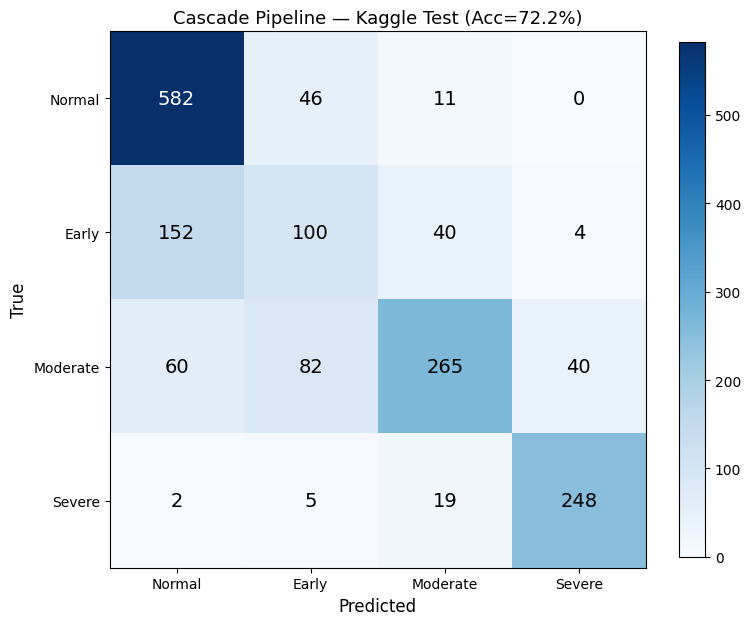

✓ nb7_cascade_cm_kaggle.png


In [7]:
# Cell 5 — Confusion Matrix (Kaggle)
cm = confusion_matrix(all_true_cascade, all_cascade_preds, labels=[0,1,2,3])
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.set_xticks(range(4)); ax.set_yticks(range(4))
short_names = ['Normal', 'Early', 'Moderate', 'Severe']
ax.set_xticklabels(short_names, fontsize=10)
ax.set_yticklabels(short_names, fontsize=10)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Cascade Pipeline — Kaggle Test (Acc={cascade_acc:.1%})', fontsize=13)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()*0.5 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(str(NB7_OUT / 'nb7_cascade_cm_kaggle.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb7_cascade_cm_kaggle.png")

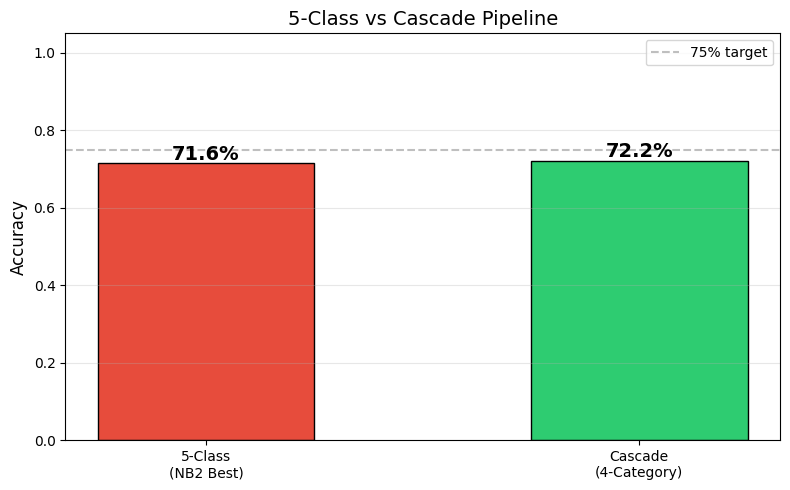

5-class best: 71.6%
Cascade (4-cat): 72.2%
Improvement: +0.6pp


In [8]:
# Cell 6 — Compare Cascade vs 5-Class
nb2_path = KOA_ROOT / 'NB2' / 'nb2_results.json'
if nb2_path.exists():
    with open(str(nb2_path)) as f:
        nb2 = json.load(f)
    best_5class_acc = nb2['best_accuracy']
else:
    best_5class_acc = 0.713

mapped_5class = np.array([kl_to_cascade(g) for g in all_true_5class])
cascade_4cat_acc = accuracy_score(mapped_5class, all_cascade_preds)

fig, ax = plt.subplots(figsize=(8, 5))
labels = ['5-Class\n(NB2 Best)', 'Cascade\n(4-Category)']
values = [best_5class_acc, cascade_4cat_acc]
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{val:.1%}", ha='center', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Class vs Cascade Pipeline', fontsize=14)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.75, color='gray', linestyle='--', alpha=0.5, label='75% target')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB7_OUT / 'nb7_cascade_vs_5class.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"5-class best: {best_5class_acc:.1%}")
print(f"Cascade (4-cat): {cascade_4cat_acc:.1%}")
print(f"Improvement: +{(cascade_4cat_acc - best_5class_acc)*100:.1f}pp")

In [9]:
# Cell 7 — Per-Stage Analysis
stage_results = []
for task, threshold, desc in [('Screening', 1, 'KL>=1'), ('OA', 2, 'KL>=2'), ('Severe', 3, 'KL>=3')]:
    true_bin = (all_true_5class >= threshold).astype(int)
    probs = np.array(all_probs[task.lower() if task != 'Screening' else 'screening'])
    preds_bin = (probs >= 0.5).astype(int)

    acc = accuracy_score(true_bin, preds_bin)
    tp = np.sum((preds_bin == 1) & (true_bin == 1))
    fn = np.sum((preds_bin == 0) & (true_bin == 1))
    fp = np.sum((preds_bin == 1) & (true_bin == 0))
    tn = np.sum((preds_bin == 0) & (true_bin == 0))
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)

    stage_results.append({'Stage': f"{task} ({desc})", 'Accuracy': acc,
                          'Sensitivity': sens, 'Specificity': spec,
                          'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn})
    print(f"{task} ({desc}): acc={acc:.4f} sens={sens:.4f} spec={spec:.4f} (TP={tp} FN={fn} FP={fp} TN={tn})")

df_stages = pd.DataFrame(stage_results)
df_stages.to_csv(str(NB7_OUT / 'nb7_stage_results.csv'), index=False)
print("\n✓ nb7_stage_results.csv")

Screening (KL>=1): acc=0.8364 sens=0.7896 spec=0.9108 (TP=803 FN=214 FP=57 TN=582)
OA (KL>=2): acc=0.8774 sens=0.8003 spec=0.9369 (TP=577 FN=144 FP=59 TN=876)
Severe (KL>=3): acc=0.9589 sens=0.9124 spec=0.9682 (TP=250 FN=24 FP=44 TN=1338)

✓ nb7_stage_results.csv


In [10]:
# Cell 8 — Evaluate on Mendeley External
ext_loader = DataLoader(KneeDataset(ext_df, val_transform), batch_size=16,
                        shuffle=False, num_workers=2, pin_memory=True)

ext_cascade_preds = []
ext_true_cascade = []

for images, labels, paths in ext_loader:
    true_cascade = np.array([kl_to_cascade(l.item()) for l in labels])
    cascade_preds, _ = cascade_predict_batch(images, models, device)
    ext_cascade_preds.extend(cascade_preds)
    ext_true_cascade.extend(true_cascade)

ext_cascade_preds = np.array(ext_cascade_preds)
ext_true_cascade = np.array(ext_true_cascade)

ext_acc = accuracy_score(ext_true_cascade, ext_cascade_preds)
ext_f1 = f1_score(ext_true_cascade, ext_cascade_preds, average='weighted')
ext_qwk = cohen_kappa_score(ext_true_cascade, ext_cascade_preds, weights='quadratic')

print("MENDELEY EXTERNAL — CASCADE PIPELINE (4-category)")
print("=" * 60)
print(f"Accuracy:     {ext_acc:.4f}")
print(f"Weighted F1:  {ext_f1:.4f}")
print(f"QWK:          {ext_qwk:.4f}")
print()
print(classification_report(ext_true_cascade, ext_cascade_preds,
                            target_names=CATEGORY_NAMES, digits=3))

print(f"\nGeneralisation gap: {(cascade_acc - ext_acc)*100:.1f}pp")

MENDELEY EXTERNAL — CASCADE PIPELINE (4-category)
Accuracy:     0.4527
Weighted F1:  0.3974
QWK:          0.5691

                    precision    recall  f1-score   support

     Normal (KL-0)      0.737     0.551     0.630       514
   Early OA (KL-1)      0.219     0.015     0.028       477
Moderate OA (KL-2)      0.110     0.207     0.143       232
Severe OA (KL-3/4)      0.513     0.958     0.668       427

          accuracy                          0.453      1650
         macro avg      0.395     0.433     0.367      1650
      weighted avg      0.441     0.453     0.397      1650


Generalisation gap: 26.9pp


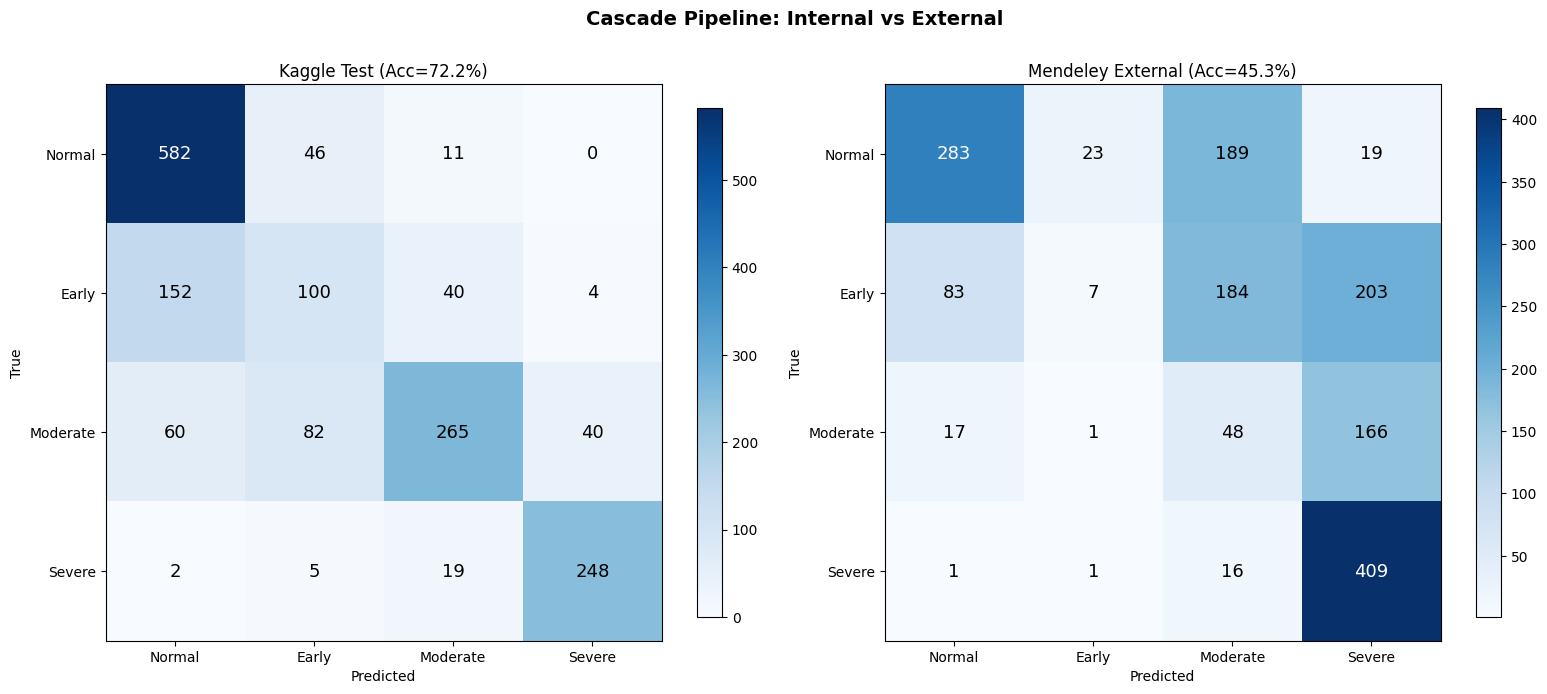

✓ nb7_cascade_cm_comparison.png


In [11]:
# Cell 9 — Confusion Matrix (External)
cm_ext = confusion_matrix(ext_true_cascade, ext_cascade_preds, labels=[0,1,2,3])
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
short_names = ['Normal', 'Early', 'Moderate', 'Severe']

for ax, matrix, title in [(axes[0], cm, f'Kaggle Test (Acc={cascade_acc:.1%})'),
                           (axes[1], cm_ext, f'Mendeley External (Acc={ext_acc:.1%})')]:
    im = ax.imshow(matrix, cmap='Blues', interpolation='nearest')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(short_names, fontsize=10)
    ax.set_yticklabels(short_names, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=12)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(matrix[i,j]), ha='center', va='center', fontsize=13,
                    color='white' if matrix[i,j] > matrix.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Cascade Pipeline: Internal vs External', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(NB7_OUT / 'nb7_cascade_cm_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb7_cascade_cm_comparison.png")

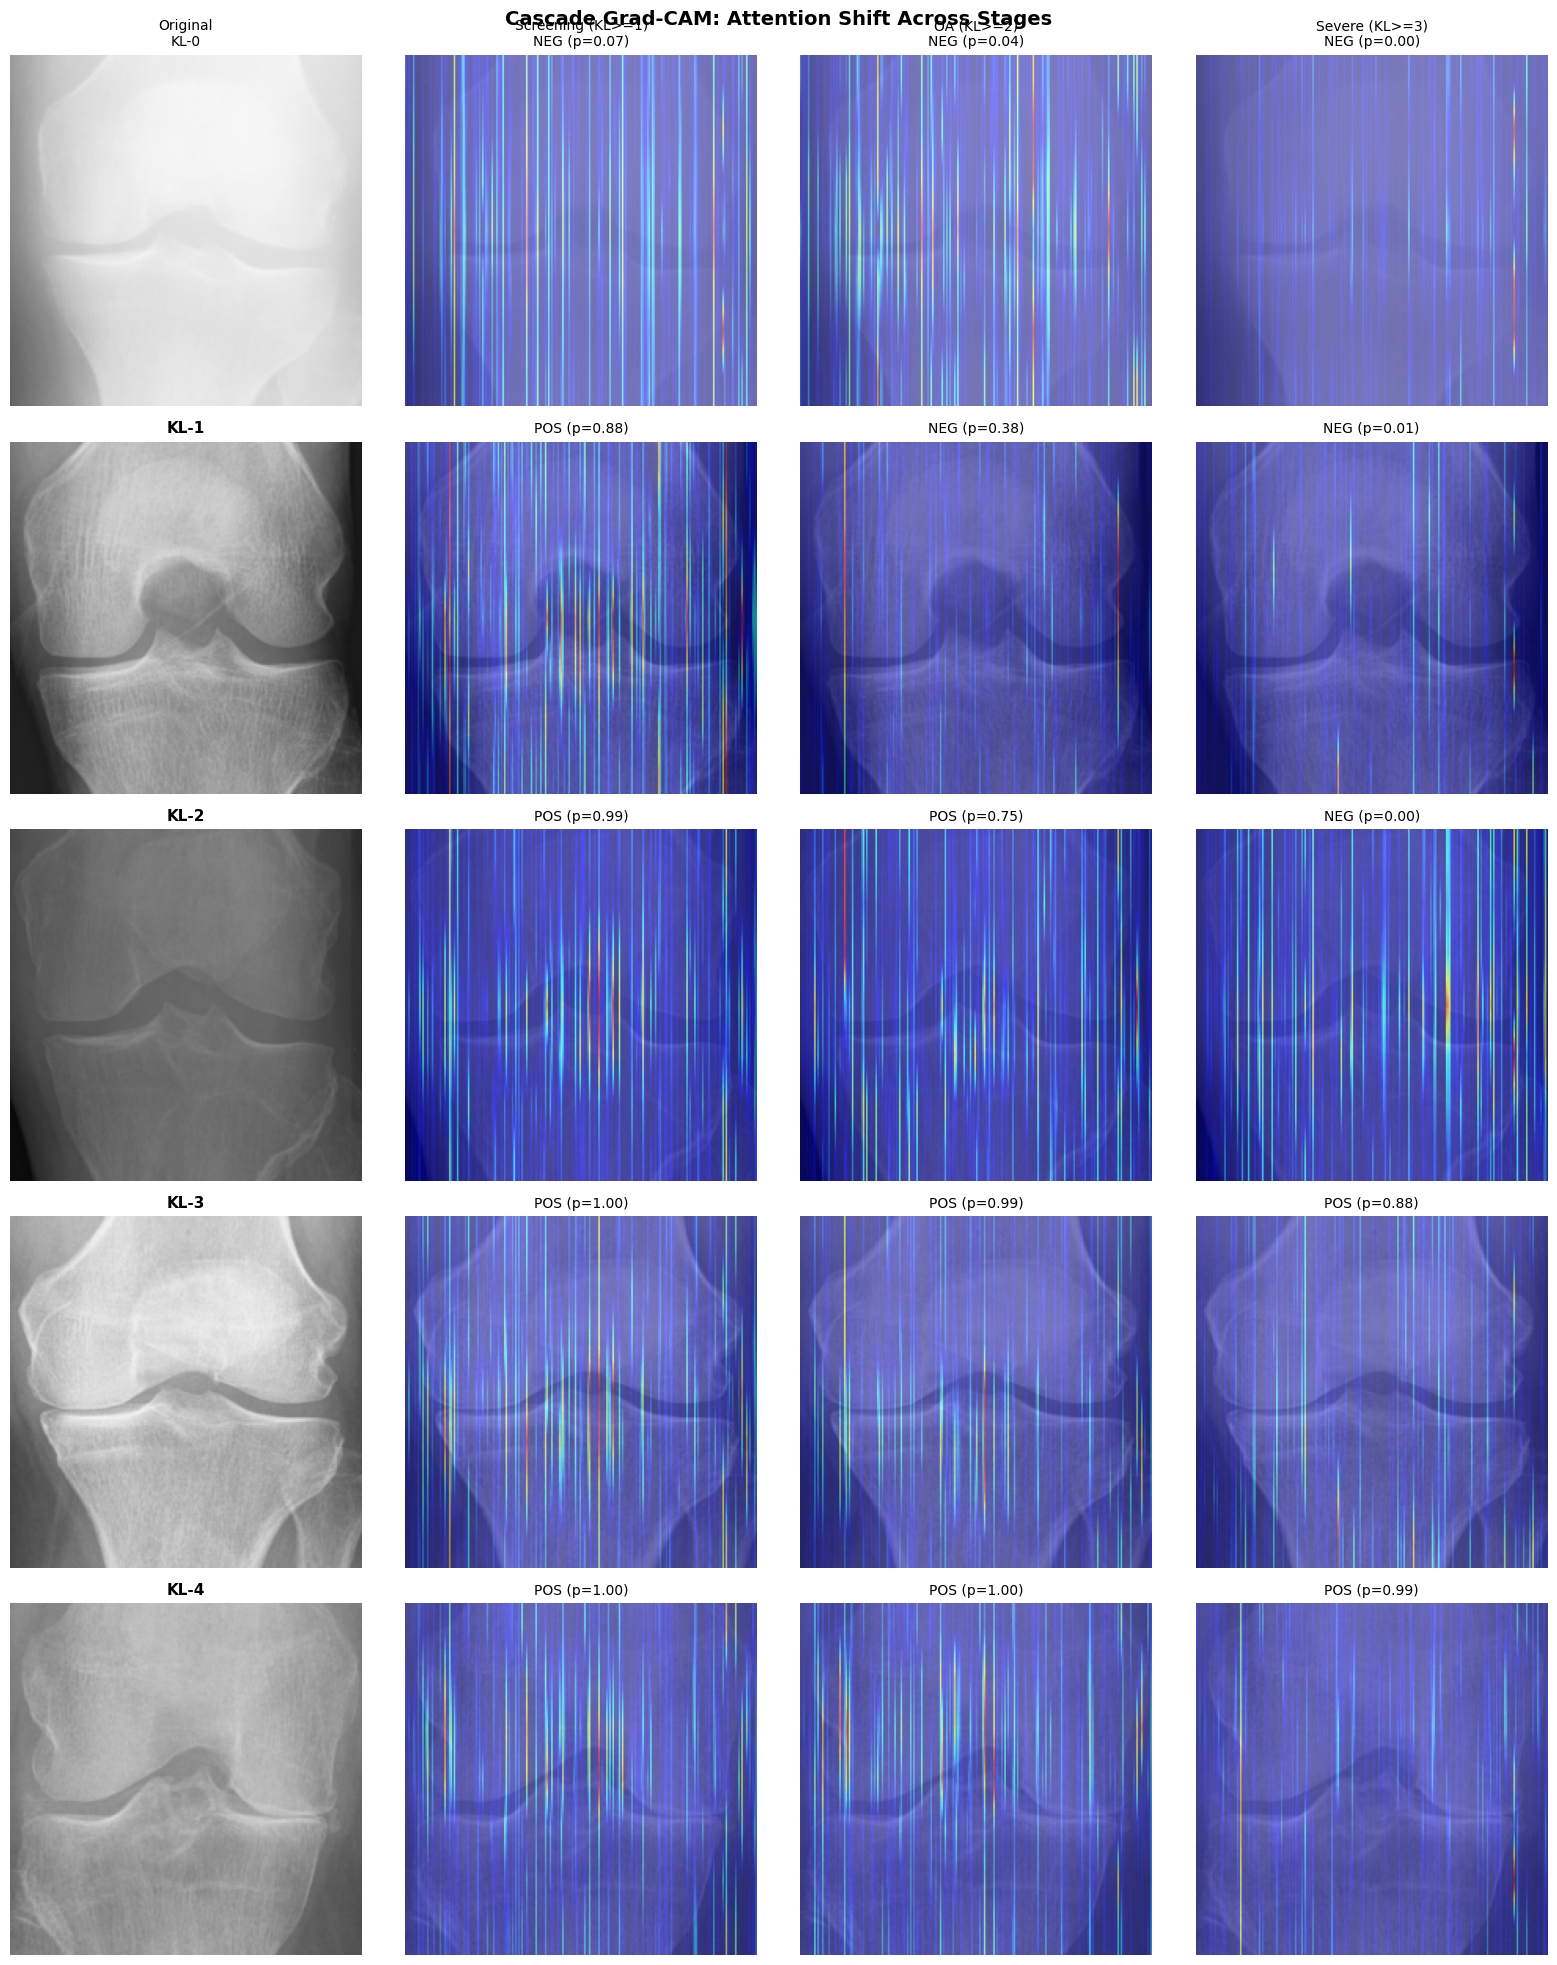

✓ nb7_cascade_gradcam.png


In [12]:
# Cell 10 — Grad-CAM: 3-Stage Attention Shift
def get_target_layer(model):
    return [model.stages[-1].blocks[-1].norm]

sample_images = []
for grade in [0, 1, 2, 3, 4]:
    s = test_df[test_df['grade'] == grade].sample(1, random_state=42)
    sample_images.append(s.iloc[0])

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
col_titles = ['Original', 'Screening (KL>=1)', 'OA (KL>=2)', 'Severe (KL>=3)']

for row_idx, row in enumerate(sample_images):
    img_pil = Image.open(row['path']).convert('RGB')
    img_vis = vis_transform(img_pil).numpy().transpose(1, 2, 0)
    img_vis = np.clip(img_vis, 0, 1)
    img_tensor = val_transform(img_pil).unsqueeze(0).to(device)

    axes[row_idx, 0].imshow(img_vis)
    axes[row_idx, 0].set_title(f'KL-{row["grade"]}', fontsize=11, fontweight='bold')
    axes[row_idx, 0].axis('off')

    for col_idx, task in enumerate(['Screening', 'OA', 'Severe']):
        model = models[task]
        target_layers = get_target_layer(model)
        cam = GradCAM(model=model, target_layers=target_layers)

        with torch.no_grad():
            out = model(img_tensor)
            pred = torch.argmax(out, dim=1).item()
            prob = torch.softmax(out, dim=1)[0, 1].item()

        grayscale_cam = cam(input_tensor=img_tensor,
                           targets=[ClassifierOutputTarget(1)])[0]
        overlay = show_cam_on_image(img_vis, grayscale_cam, use_rgb=True)

        axes[row_idx, col_idx + 1].imshow(overlay)
        label = "POS" if pred == 1 else "NEG"
        axes[row_idx, col_idx + 1].set_title(f'{label} (p={prob:.2f})', fontsize=10)
        axes[row_idx, col_idx + 1].axis('off')
        del cam

for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(f'{title}\n{axes[0, col_idx].get_title()}', fontsize=10)

plt.suptitle('Cascade Grad-CAM: Attention Shift Across Stages', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(NB7_OUT / 'nb7_cascade_gradcam.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb7_cascade_gradcam.png")

95% sensitivity threshold: 0.10
  Sensitivity: 0.9558
  Specificity: 0.5086


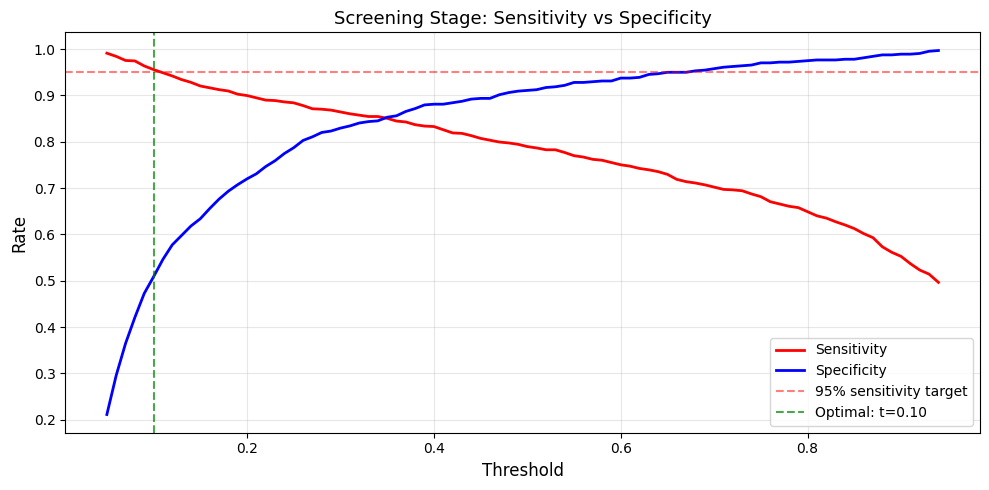

✓ nb7_screening_thresholds.png


In [13]:
# Cell 11 — Clinical Threshold Tuning (High-Sensitivity Screening)
screen_probs = np.array(all_probs['screening'])
screen_true = (all_true_5class >= 1).astype(int)

thresholds = np.arange(0.05, 0.95, 0.01)
results = []
for t in thresholds:
    pred = (screen_probs >= t).astype(int)
    tp = np.sum((pred == 1) & (screen_true == 1))
    fn = np.sum((pred == 0) & (screen_true == 1))
    fp = np.sum((pred == 1) & (screen_true == 0))
    tn = np.sum((pred == 0) & (screen_true == 0))
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    results.append({'threshold': t, 'sensitivity': sens, 'specificity': spec})

df_thresh = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_thresh['threshold'], df_thresh['sensitivity'], 'r-', linewidth=2, label='Sensitivity')
ax.plot(df_thresh['threshold'], df_thresh['specificity'], 'b-', linewidth=2, label='Specificity')
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% sensitivity target')

high_sens = df_thresh[df_thresh['sensitivity'] >= 0.95]
if len(high_sens) > 0:
    best_row = high_sens.loc[high_sens['threshold'].idxmax()]
    ax.axvline(x=best_row['threshold'], color='green', linestyle='--', alpha=0.7,
               label=f'Optimal: t={best_row["threshold"]:.2f}')
    print(f"95% sensitivity threshold: {best_row['threshold']:.2f}")
    print(f"  Sensitivity: {best_row['sensitivity']:.4f}")
    print(f"  Specificity: {best_row['specificity']:.4f}")

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Rate', fontsize=12)
ax.set_title('Screening Stage: Sensitivity vs Specificity', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB7_OUT / 'nb7_screening_thresholds.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb7_screening_thresholds.png")

In [14]:
# Cell 12 — Cascade with Tuned Screening Threshold
high_sens = df_thresh[df_thresh['sensitivity'] >= 0.95]
tuned_threshold = high_sens['threshold'].max() if len(high_sens) > 0 else 0.3

def cascade_predict_tuned(images, models, device, screen_thresh=0.5):
    with torch.no_grad():
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            screen_out = models['Screening'](images)
            oa_out = models['OA'](images)
            severe_out = models['Severe'](images)

    screen_prob = torch.softmax(screen_out, dim=1)[:, 1].cpu().numpy()
    oa_prob = torch.softmax(oa_out, dim=1)[:, 1].cpu().numpy()
    severe_prob = torch.softmax(severe_out, dim=1)[:, 1].cpu().numpy()

    cascade_labels = []
    for i in range(len(images)):
        if screen_prob[i] < screen_thresh:
            cascade_labels.append(0)
        elif oa_prob[i] < 0.5:
            cascade_labels.append(1)
        elif severe_prob[i] < 0.5:
            cascade_labels.append(2)
        else:
            cascade_labels.append(3)
    return np.array(cascade_labels)

tuned_preds = []
tuned_true = []
for images, labels, paths in test_loader:
    true_cascade = np.array([kl_to_cascade(l.item()) for l in labels])
    preds = cascade_predict_tuned(images, models, device, screen_thresh=tuned_threshold)
    tuned_preds.extend(preds)
    tuned_true.extend(true_cascade)

tuned_preds = np.array(tuned_preds)
tuned_true = np.array(tuned_true)
tuned_acc = accuracy_score(tuned_true, tuned_preds)
tuned_f1 = f1_score(tuned_true, tuned_preds, average='weighted')

print(f"Tuned screening threshold: {tuned_threshold:.2f}")
print(f"Default (t=0.50): acc={cascade_acc:.4f} F1={cascade_f1:.4f}")
print(f"Tuned   (t={tuned_threshold:.2f}): acc={tuned_acc:.4f} F1={tuned_f1:.4f}")

screen_true_bin = (all_true_5class >= 1).astype(int)
tuned_screen_pred = (np.array(all_probs['screening']) >= tuned_threshold).astype(int)
missed = np.sum((tuned_screen_pred == 0) & (screen_true_bin == 1))
total_pos = np.sum(screen_true_bin == 1)
print(f"\nMissed OA cases (FN): {missed}/{total_pos} ({100*missed/total_pos:.1f}%)")

Tuned screening threshold: 0.10
Default (t=0.50): acc=0.7216 F1=0.7085
Tuned   (t=0.10): acc=0.6359 F1=0.6569

Missed OA cases (FN): 45/1017 (4.4%)


In [15]:
# Cell 13 — Save Results
nb7_results = {
    'cascade_kaggle_acc': float(cascade_acc),
    'cascade_kaggle_f1': float(cascade_f1),
    'cascade_kaggle_qwk': float(cascade_qwk),
    'cascade_external_acc': float(ext_acc),
    'cascade_external_f1': float(ext_f1),
    'cascade_external_qwk': float(ext_qwk),
    'gen_gap_pp': float((cascade_acc - ext_acc) * 100),
    'best_5class_acc': float(best_5class_acc),
    'cascade_improvement_pp': float((cascade_4cat_acc - best_5class_acc) * 100),
    'tuned_threshold': float(tuned_threshold),
    'tuned_acc': float(tuned_acc),
    'categories': CATEGORY_NAMES,
    'architecture': BEST_ARCH,
    'stages': {
        'Screening': {'task': 'KL>=1'},
        'OA': {'task': 'KL>=2'},
        'Severe': {'task': 'KL>=3'},
    },
}
with open(str(NB7_OUT / 'nb7_results.json'), 'w') as f:
    json.dump(nb7_results, f, indent=2)

for fn in ['nb7_results.json', 'nb7_cascade_cm_kaggle.png', 'nb7_cascade_vs_5class.png',
           'nb7_stage_results.csv', 'nb7_cascade_cm_comparison.png',
           'nb7_cascade_gradcam.png', 'nb7_screening_thresholds.png']:
    print(f"  {'✓' if (NB7_OUT / fn).exists() else '✗'} {fn}")

  ✓ nb7_results.json
  ✓ nb7_cascade_cm_kaggle.png
  ✓ nb7_cascade_vs_5class.png
  ✓ nb7_stage_results.csv
  ✓ nb7_cascade_cm_comparison.png
  ✓ nb7_cascade_gradcam.png
  ✓ nb7_screening_thresholds.png
